# Financial News Exploratory Data Analysis

## Nova Financial Solutions — Task 1

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from wordcloud import WordCloud

In [2]:
import sklearn
import wordcloud

print("Everything works!")

Everything works!


In [3]:
import sklearn
import wordcloud

print("Everything works!")

Everything works!


In [4]:
import pandas as pd

df = pd.read_csv("../data/raw_analyst_ratings.csv")
df.head()

FileNotFoundError: [Errno 2] No such file or directory: '../data/raw_analyst_ratings.csv'

In [ ]:
df.columns

Index(['Unnamed: 0', 'headline', 'url', 'publisher', 'date', 'stock'], dtype='str')

In [ ]:
df.shape

(1407328, 6)

In [ ]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1407328 entries, 0 to 1407327
Data columns (total 6 columns):
 #   Column      Non-Null Count    Dtype
---  ------      --------------    -----
 0   Unnamed: 0  1407328 non-null  int64
 1   headline    1407328 non-null  str  
 2   url         1407328 non-null  str  
 3   publisher   1407328 non-null  str  
 4   date        1407328 non-null  str  
 5   stock       1407328 non-null  str  
dtypes: int64(1), str(5)
memory usage: 64.4 MB


In [ ]:
df.isnull().sum()

Unnamed: 0    0
headline      0
url           0
publisher     0
date          0
stock         0
dtype: int64

## Dataset Overview

This dataset contains financial news headlines, publishers, and publication timestamps. It will be used to analyze sentiment, publishing patterns, and their relationship with stock price movements.

In [ ]:
df["headline_length"] = df["headline"].astype(str).apply(len)
df["headline_length"].describe()

count    1.407328e+06
mean     7.312051e+01
std      4.073531e+01
min      3.000000e+00
25%      4.700000e+01
50%      6.400000e+01
75%      8.700000e+01
max      5.120000e+02
Name: headline_length, dtype: float64

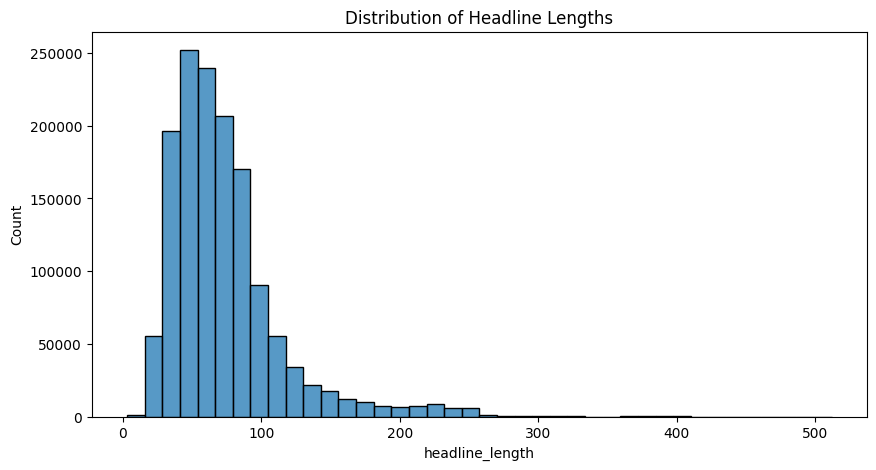

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10,5))
sns.histplot(df["headline_length"], bins=40)
plt.title("Distribution of Headline Lengths")
plt.show()

In [ ]:
df["publisher"].value_counts().head(10)

publisher
Paul Quintaro        228373
Lisa Levin           186979
Benzinga Newsdesk    150484
Charles Gross         96732
Monica Gerson         82380
Eddie Staley          57254
Hal Lindon            49047
ETF Professor         28489
Juan Lopez            28438
Benzinga Staff        28114
Name: count, dtype: int64

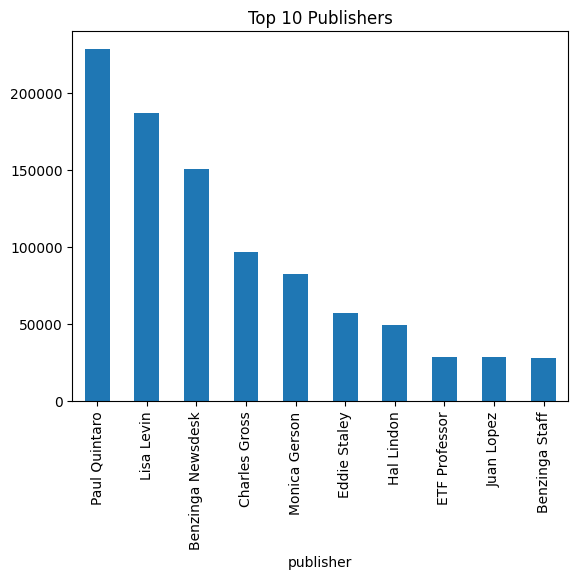

In [ ]:
df["publisher"].value_counts().head(10).plot(kind="bar")
plt.title("Top 10 Publishers")
plt.show()

In [ ]:
df["date"] = pd.to_datetime(df["date"], errors="coerce")
df["day"] = df["date"].dt.date

In [ ]:
daily_news = df.groupby("day").size()
daily_news.head()

day
2011-04-27    1
2011-04-28    2
2011-04-29    2
2011-04-30    1
2011-05-01    1
dtype: int64

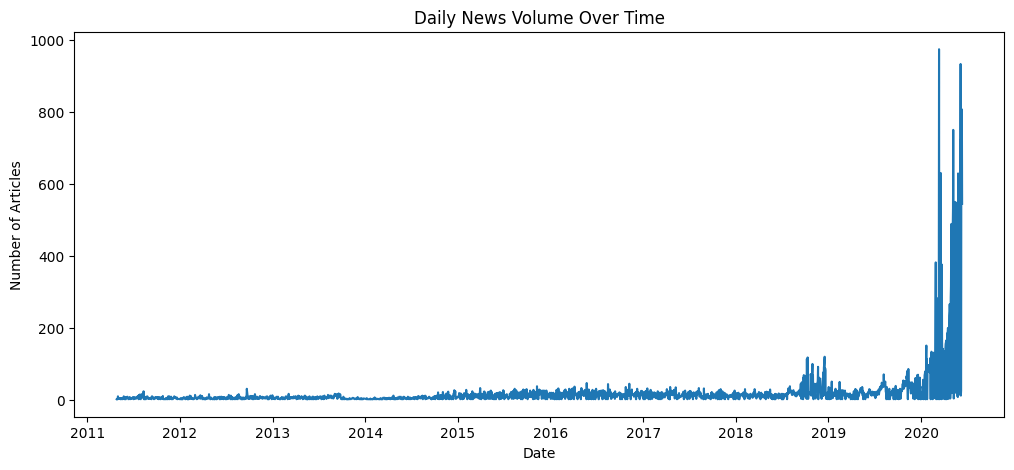

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,5))
daily_news.plot()
plt.title("Daily News Volume Over Time")
plt.xlabel("Date")
plt.ylabel("Number of Articles")
plt.show()

## Time Series Insight

News volume fluctuates significantly over time, showing periods of high activity which may correspond to major market or economic events.

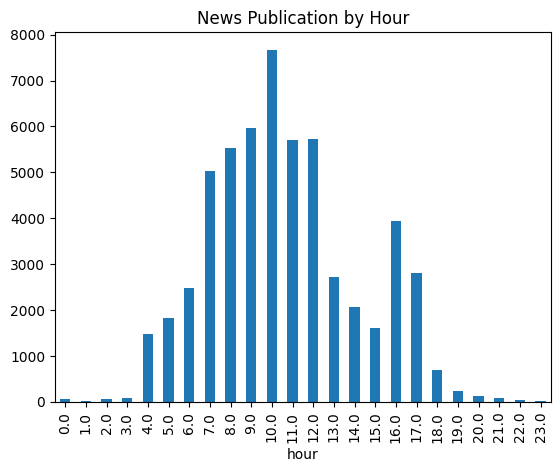

In [ ]:
df["hour"] = df["date"].dt.hour
df["hour"].value_counts().sort_index().plot(kind="bar")
plt.title("News Publication by Hour")
plt.show()

In [ ]:
from sklearn.feature_extraction.text import CountVectorizer

vectorizer = CountVectorizer(stop_words="english", max_features=20)
X = vectorizer.fit_transform(df["headline"])

words = vectorizer.get_feature_names_out()
counts = X.toarray().sum(axis=0)

word_freq = dict(zip(words, counts))
word_freq

{'announces': np.int64(66591),
 'benzinga': np.int64(74516),
 'buy': np.int64(64371),
 'downgrades': np.int64(61959),
 'earnings': np.int64(87399),
 'eps': np.int64(128897),
 'est': np.int64(140604),
 'market': np.int64(120558),
 'mid': np.int64(62263),
 'price': np.int64(64407),
 'pt': np.int64(73068),
 'raises': np.int64(57802),
 'reports': np.int64(108710),
 'sales': np.int64(79645),
 'shares': np.int64(114313),
 'stocks': np.int64(161776),
 'trading': np.int64(61182),
 'update': np.int64(91723),
 'vs': np.int64(162099),
 'week': np.int64(69572)}

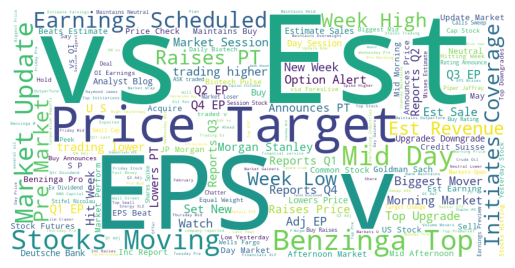

In [ ]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt

text = " ".join(df["headline"].astype(str))

wordcloud = WordCloud(width=800, height=400, background_color="white").generate(text)

plt.imshow(wordcloud)
plt.axis("off")
plt.show()

## Keyword Analysis Insight

Common terms such as financial actions, earnings, and price movements dominate headlines, indicating that news is heavily focused on market-relevant events.